# Démonstration : réseau de neurones

Ce notebook accompagne la section sur les réseaux de neurones.
Il permet de : 

- charger des données numériques ;
- créer un petit réseau ;
- observer ses prédictions avant l’entraînement ;
- l’entraîner en réduisant une fonction de perte ;
- comparer les prédictions avant et après ;
- modifier quelques paramètres pour voir ce qui change.

## 1. Importer les bibliothèques

On utilise :

- `numpy` pour les calculs ;
- `matplotlib` pour afficher les images et les courbes ;
- `scikit-learn` pour charger un petit jeu de données et séparer entraînement/test.

Le réseau lui-même sera écrit à la main. Il existe des bibliothèques comme PyTorch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Pour rendre la démonstration reproductible.
np.random.seed(42)

## 2. Charger un petit corpus d’images

Le jeu de données `digits` contient des images manuscrites de chiffres de 0 à 9.
Chaque image est représentée comme une ligne de **64 nombres**.

In [2]:
digits = load_digits()

X = digits.data          # Données : une ligne = une image, 64 colonnes = 64 pixels
y = digits.target        # Étiquette : le chiffre attendu, de 0 à 9

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("Classes possibles :", np.unique(y))

Forme de X : (1797, 64)
Forme de y : (1797,)
Classes possibles : [0 1 2 3 4 5 6 7 8 9]


## 3. Quelques exemples

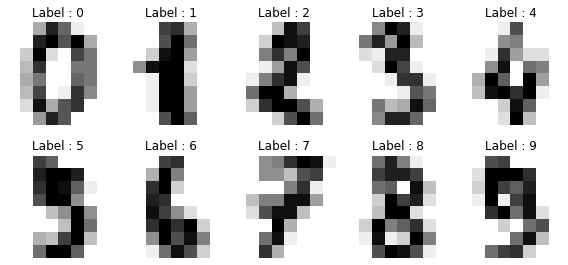

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Label : {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Préparer les données

On doit :

- normaliser les pixels entre 0 et 1 ;
- transformer les étiquettes en vecteurs `one-hot` ;
- séparer les données en entraînement et test.

Un label `3` devient par exemple :

```text
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

In [4]:
# Les pixels vont de 0 à 16. On les ramène entre 0 et 1.
X = X / 16.0

# Encodage one-hot des classes.
num_classes = len(np.unique(y))
y_onehot = np.eye(num_classes)[y]

X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
    X,
    y_onehot,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Entraînement :", X_train.shape)
print("Test :", X_test.shape)
print("Exemple d'étiquette one-hot :", y_onehot[0])

Entraînement : (1347, 64)
Test : (450, 64)
Exemple d'étiquette one-hot : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 5. Définir un petit réseau

Notre réseau a une architecture très simple :

```text
64 pixels → couche cachée → 10 probabilités
```

La sortie contient une probabilité pour chaque chiffre possible.

À retenir :

- les **poids** indiquent quels signaux comptent davantage ;
- les **biais** décalent les calculs ;
- **ReLU** coupe les valeurs négatives ;
- **softmax** transforme la sortie en probabilités ;
- la **perte** mesure l’erreur ;
- l’entraînement ajuste les poids pour réduire cette erreur.

In [5]:
class NeuralNet:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        rng = np.random.default_rng(seed)

        # Initialisation des poids.
        # Ici on utilise une initialisation adaptée à ReLU.
        self.W1 = rng.normal(0, np.sqrt(2 / input_size), size=(input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = rng.normal(0, np.sqrt(2 / hidden_size), size=(hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        """ReLU(x) = max(0, x)."""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Dérivée de ReLU : 1 si z > 0, sinon 0."""
        return (z > 0).astype(float)

    def softmax(self, z):
        """Transforme les scores en probabilités."""
        shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        """Propagation avant : entrée → couche cachée → sortie."""
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def compute_loss(self, y_true, y_pred):
        """Entropie croisée : mesure l'écart entre prédiction et réponse attendue."""
        eps = 1e-12
        return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

    def backward(self, X, y_true, learning_rate):
        """Rétropropagation : ajuste les poids pour réduire la perte."""
        m = X.shape[0]

        # Erreur à la sortie.
        dz2 = self.a2 - y_true
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Erreur dans la couche cachée.
        dz1 = (dz2 @ self.W2.T) * self.relu_derivative(self.z1)
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Mise à jour des paramètres.
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def predict(self, X):
        """Retourne la classe la plus probable."""
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)

    def accuracy(self, X, y_true):
        """Calcule la proportion de bonnes réponses."""
        predictions = self.predict(X)
        expected = np.argmax(y_true, axis=1)
        return np.mean(predictions == expected)

    def train(self, X, y, X_val, y_val, epochs=40, batch_size=32, learning_rate=0.1):
        """Entraîne le réseau et conserve l'historique."""
        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
        }

        for epoch in range(epochs):
            # Mélanger les données à chaque epoch.
            permutation = np.random.permutation(X.shape[0])
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            # Entraînement par mini-lots.
            for start in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[start:start + batch_size]
                y_batch = y_shuffled[start:start + batch_size]

                self.forward(X_batch)
                self.backward(X_batch, y_batch, learning_rate)

            # Mesures à la fin de chaque epoch.
            train_pred = self.forward(X)
            val_pred = self.forward(X_val)

            train_loss = self.compute_loss(y, train_pred)
            val_loss = self.compute_loss(y_val, val_pred)
            train_acc = self.accuracy(X, y)
            val_acc = self.accuracy(X_val, y_val)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            if epoch == 0 or (epoch + 1) % 10 == 0 or epoch == epochs - 1:
                print(
                    f"Epoch {epoch + 1:02d}/{epochs} | "
                    f"perte train={train_loss:.3f} | "
                    f"perte test={val_loss:.3f} | "
                    f"accuracy test={val_acc:.1%}"
                )

        return history

## 6. Créer le modèle

On crée maintenant un réseau avec :

- 64 entrées, une par pixel ;
- une couche cachée de 32 neurones ;
- 10 sorties, une par chiffre possible.

À ce stade, les poids sont presque aléatoires. Le réseau n’a encore rien appris.

In [6]:
net = NeuralNet(input_size=64, hidden_size=32, output_size=10)

print("W1 :", net.W1.shape)
print("b1 :", net.b1.shape)
print("W2 :", net.W2.shape)
print("b2 :", net.b2.shape)

print("Accuracy avant entraînement :", f"{net.accuracy(X_test, y_test):.1%}")

W1 : (64, 32)
b1 : (1, 32)
W2 : (32, 10)
b2 : (1, 10)
Accuracy avant entraînement : 1.1%


## 7. Voir les prédictions avant l’entraînement

Avant l’entraînement, le modèle répond presque au hasard.

C’est normal : ses poids n’ont pas encore été ajustés.

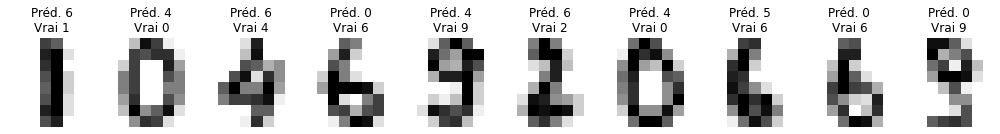

In [7]:
def show_predictions(model, X, y_labels, count=10, seed=0):
    rng = np.random.default_rng(seed)
    indices = rng.choice(X.shape[0], count, replace=False)

    X_sample = X[indices]
    true_labels = y_labels[indices]
    predicted_labels = model.predict(X_sample)

    fig, axes = plt.subplots(1, count, figsize=(1.4 * count, 2.2))

    if count == 1:
        axes = [axes]

    for ax, image, true, pred in zip(axes, X_sample, true_labels, predicted_labels):
        ax.imshow(image.reshape(8, 8), cmap="gray_r")
        ax.set_title(f"Préd. {pred}\nVrai {true}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(net, X_test, labels_test, count=10, seed=1)

## 8. Entraîner le réseau

Le cycle d’entraînement est toujours le même :

1. le modèle prédit ;
2. on mesure l’erreur ;
3. on ajuste les poids ;
4. on recommence.

Pendant la démonstration, on peut modifier `learning_rate`, `hidden_size` ou `epochs` pour voir ce qui change.

In [8]:
hidden_size = 32
learning_rate = 0.1
epochs = 40
batch_size = 32

net = NeuralNet(input_size=64, hidden_size=hidden_size, output_size=10, seed=42)

history = net.train(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
)

print()
print("Accuracy finale sur le test :", f"{net.accuracy(X_test, y_test):.1%}")

Epoch 01/40 | perte train=1.755 | perte test=1.767 | accuracy test=45.1%
Epoch 10/40 | perte train=0.204 | perte test=0.238 | accuracy test=92.4%
Epoch 20/40 | perte train=0.117 | perte test=0.170 | accuracy test=94.2%
Epoch 30/40 | perte train=0.079 | perte test=0.145 | accuracy test=95.8%
Epoch 40/40 | perte train=0.081 | perte test=0.153 | accuracy test=94.9%

Accuracy finale sur le test : 94.9%


Epoch 20/40 | perte train=0.117 | perte test=0.170 | accuracy test=94.2%
Epoch 30/40 | perte train=0.079 | perte test=0.145 | accuracy test=95.8%


Epoch 40/40 | perte train=0.081 | perte test=0.153 | accuracy test=94.9%

Accuracy finale sur le test : 94.9%


## 9. Observer la perte et l’accuracy

Si l’entraînement fonctionne, la perte devrait globalement descendre.

L’accuracy devrait, elle, globalement monter.

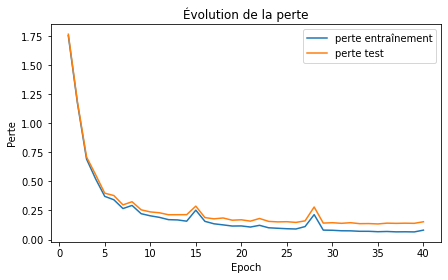

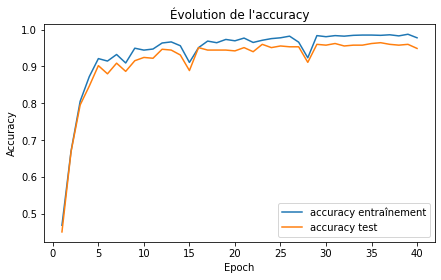

In [9]:
epochs_range = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_loss"], label="perte entraînement")
plt.plot(epochs_range, history["val_loss"], label="perte test")
plt.xlabel("Epoch")
plt.ylabel("Perte")
plt.title("Évolution de la perte")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history["train_acc"], label="accuracy entraînement")
plt.plot(epochs_range, history["val_acc"], label="accuracy test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()
plt.show()

## 10. Voir les prédictions après l’entraînement

On regarde maintenant les mêmes exemples.

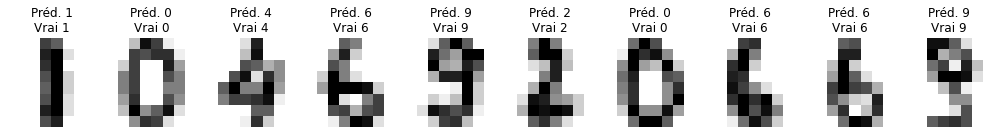

In [10]:
show_predictions(net, X_test, labels_test, count=10, seed=1)

## 11. Regarder les erreurs

Les erreurs sont souvent plus intéressantes que les bonnes réponses.

Elles permettent de voir quand deux chiffres se ressemblent, ou quand l’image est ambiguë.

Nombre d'erreurs : 23 sur 450


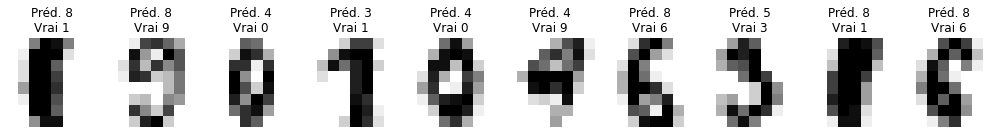

In [11]:
predictions = net.predict(X_test)
mistakes = np.where(predictions != labels_test)[0]

print("Nombre d'erreurs :", len(mistakes), "sur", len(labels_test))

if len(mistakes) > 0:
    count = min(10, len(mistakes))
    selected = mistakes[:count]

    fig, axes = plt.subplots(1, count, figsize=(1.4 * count, 2.2))

    if count == 1:
        axes = [axes]

    for ax, index in zip(axes, selected):
        ax.imshow(X_test[index].reshape(8, 8), cmap="gray_r")
        ax.set_title(f"Préd. {predictions[index]}\nVrai {labels_test[index]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 12. À tester pendant la démonstration

On peut maintenant modifier un paramètre et relancer l’entraînement.

Quelques idées :

- réduire `epochs` pour voir un modèle sous-entraîné ;
- augmenter ou diminuer `learning_rate` ;
- changer `hidden_size` ;
- observer si la perte descend plus vite, plus lentement ou devient instable.

In [32]:
# Essayez de modifier ces valeurs.
demo_hidden_size = 16
demo_learning_rate = 0.02
demo_epochs = 15
demo_batch_size = 32

demo_net = NeuralNet(input_size=64, hidden_size=demo_hidden_size, output_size=10, seed=123)

demo_history = demo_net.train(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=demo_epochs,
    batch_size=demo_batch_size,
    learning_rate=demo_learning_rate,
)

print()
print("Accuracy avec ces paramètres :", f"{demo_net.accuracy(X_test, y_test):.1%}")

Epoch 01/15 | perte train=2.115 | perte test=2.115 | accuracy test=20.9%
Epoch 10/15 | perte train=1.061 | perte test=1.069 | accuracy test=80.0%
Epoch 15/15 | perte train=0.707 | perte test=0.715 | accuracy test=85.3%

Accuracy avec ces paramètres : 85.3%
